Dataset root found: /kaggle/input/dataset-challenge2-dl/dataset challenge 2 dl 


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 138MB/s] 


Epoch 1/20


100%|██████████| 16/16 [00:18<00:00,  1.18s/it]


Train F1: 0.2470 | Val F1: 0.1612
Epoch 2/20


...

Train F1: 0.9342 | Val F1: 0.3442
Epoch 19/20


100%|██████████| 16/16 [00:17<00:00,  1.07s/it]


Train F1: 0.9003 | Val F1: 0.3519
Epoch 20/20


100%|██████████| 16/16 [00:16<00:00,  1.06s/it]


Train F1: 0.9372 | Val F1: 0.3382


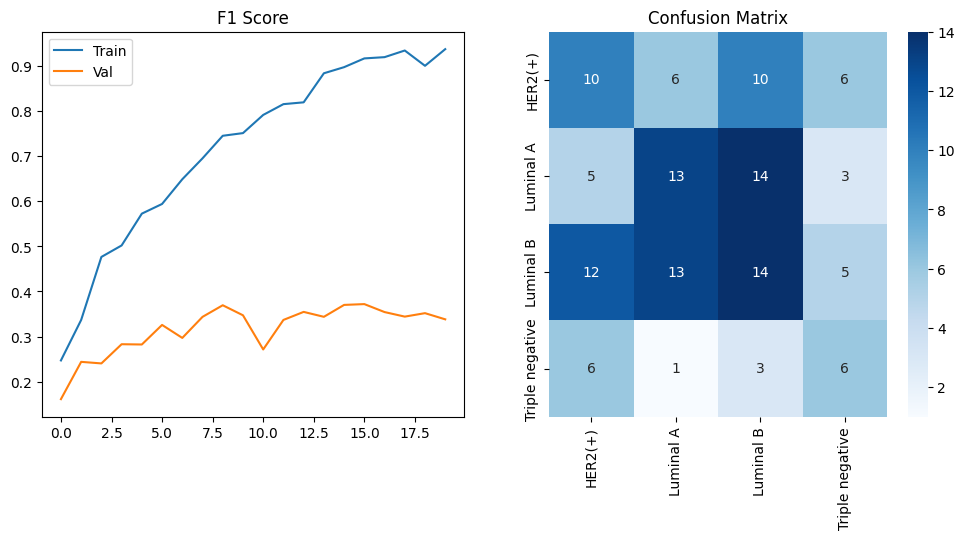

100%|██████████| 15/15 [00:34<00:00,  2.27s/it]

Submission salvata.


In [3]:
import os
import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

# --- 1. CONFIGURAZIONE DINAMICA ---

def find_base_path(root_dir, target_file="train_labels.csv"):
    """Trova la cartella base corretta cercando il file delle label."""
    for root, dirs, files in os.walk(root_dir):
        if target_file in files:
            return root
    raise FileNotFoundError(f"Impossibile trovare {target_file} in {root_dir}")

# Rilevamento automatico del percorso
SEARCH_ROOT = "/kaggle/input"
try:
    BASE_PATH = find_base_path(SEARCH_ROOT)
    print(f"Dataset root found: {BASE_PATH}")
except FileNotFoundError as e:
    print(e)
    exit()

# Definizione percorsi (Logica: Train -> train_data, Test -> test_data)
TRAIN_LABELS_PATH = os.path.join(BASE_PATH, "train_labels.csv")
TRAIN_IMG_DIR = os.path.join(BASE_PATH, "train_data/images")
TRAIN_MASK_DIR = os.path.join(BASE_PATH, "train_data/masks")
TEST_IMG_DIR = os.path.join(BASE_PATH, "test_data/images")
TEST_MASK_DIR = os.path.join(BASE_PATH, "test_data/masks")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 32
EPOCHS = 20
IMG_SIZE = 224
LEARNING_RATE = 1e-4

# --- 2. DATASET CLASS ---

def crop_tissue(img, mask):
    """Crop sulla ROI definita dalla maschera per ridurre il rumore."""
    if np.sum(mask) == 0:
        return img
    rows, cols = np.where(mask > 0)
    y_min, y_max = np.min(rows), np.max(rows)
    x_min, x_max = np.min(cols), np.max(cols)
    return img[y_min:y_max+1, x_min:x_max+1]

class TissueDataset(Dataset):
    def __init__(self, dataframe, img_dir, mask_dir, transform=None, is_test=False):
        self.df = dataframe
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.is_test = is_test

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_name = row['sample_index'] if not self.is_test else row['filename']
        mask_name = img_name.replace("img", "mask") # Convenzione img_ -> mask_
        
        img_path = os.path.join(self.img_dir, img_name)
        mask_path = os.path.join(self.mask_dir, mask_name)
        
        try:
            image = cv2.imread(img_path)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            
            if mask is not None:
                image = crop_tissue(image, mask)
                
            image = Image.fromarray(image)
        except Exception:
            # Fallback per evitare crash in caso di file corrotto
            image = Image.new('RGB', (IMG_SIZE, IMG_SIZE))
            
        if self.transform:
            image = self.transform(image)
            
        if self.is_test:
            return image, img_name
        else:
            label = row['label_encoded']
            return image, torch.tensor(label, dtype=torch.long)

# --- 3. DATA LOADING ---

def get_data_loaders():
    df = pd.read_csv(TRAIN_LABELS_PATH)
    
    # Filtro validità file
    valid_rows = []
    for _, row in df.iterrows():
        img_name = row['sample_index']
        mask_name = img_name.replace("img", "mask")
        if os.path.exists(os.path.join(TRAIN_IMG_DIR, img_name)):
            valid_rows.append(row)
    
    df = pd.DataFrame(valid_rows)
    
    # Encoding
    le = LabelEncoder()
    df['label_encoded'] = le.fit_transform(df['label'])
    
    # Split
    train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)
    
    # Weighted Sampler per bilanciamento classi
    class_counts = train_df['label_encoded'].value_counts().sort_index().values
    class_weights = 1. / class_counts
    sample_weights = [class_weights[l] for l in train_df['label_encoded']]
    sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)
    
    # Transforms
    train_trans = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(90),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    
    val_trans = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    
    train_loader = DataLoader(TissueDataset(train_df, TRAIN_IMG_DIR, TRAIN_MASK_DIR, train_trans), 
                              batch_size=BATCH_SIZE, sampler=sampler, num_workers=2)
    val_loader = DataLoader(TissueDataset(val_df, TRAIN_IMG_DIR, TRAIN_MASK_DIR, val_trans), 
                            batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    
    return train_loader, val_loader, le

# --- 4. MODELLO (ResNet50) ---

def get_model(num_classes):
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(DEVICE)

# --- 5. TRAINING ---

def train():
    train_loader, val_loader, le = get_data_loaders()
    model = get_model(len(le.classes_))
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    
    history = {'t_loss': [], 'v_loss': [], 't_f1': [], 'v_f1': []}
    
    for epoch in range(EPOCHS):
        model.train()
        t_loss, all_preds, all_lbls = 0.0, [], []
        
        print(f"Epoch {epoch+1}/{EPOCHS}")
        for imgs, lbls in tqdm(train_loader):
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, lbls)
            loss.backward()
            optimizer.step()
            
            t_loss += loss.item()
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_lbls.extend(lbls.cpu().numpy())
            
        # Validation
        model.eval()
        v_loss, v_preds, v_lbls = 0.0, [], []
        with torch.no_grad():
            for imgs, lbls in val_loader:
                imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
                out = model(imgs)
                v_loss += criterion(out, lbls).item()
                v_preds.extend(out.argmax(1).cpu().numpy())
                v_lbls.extend(lbls.cpu().numpy())
        
        # Metrics
        t_f1 = f1_score(all_lbls, all_preds, average='macro')
        v_f1 = f1_score(v_lbls, v_preds, average='macro')
        
        history['t_loss'].append(t_loss/len(train_loader))
        history['v_loss'].append(v_loss/len(val_loader))
        history['t_f1'].append(t_f1)
        history['v_f1'].append(v_f1)
        
        print(f"Train F1: {t_f1:.4f} | Val F1: {v_f1:.4f}")

    return model, history, le, v_lbls, v_preds

# --- ESECUZIONE ---

if __name__ == "__main__":
    model, history, le, v_lbls, v_preds = train()

    # Plots
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history['t_f1'], label='Train')
    plt.plot(history['v_f1'], label='Val')
    plt.title('F1 Score')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    sns.heatmap(confusion_matrix(v_lbls, v_preds), annot=True, fmt='d', 
                xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
    plt.title('Confusion Matrix')
    plt.show()

    # Submission
    test_files = [f for f in os.listdir(TEST_IMG_DIR) if f.endswith('.png')]
    test_df = pd.DataFrame({'filename': test_files})
    test_ds = TissueDataset(test_df, TEST_IMG_DIR, TEST_MASK_DIR, 
                            transform=transforms.Compose([
                                transforms.Resize((IMG_SIZE, IMG_SIZE)),
                                transforms.ToTensor(),
                                transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
                            ]), is_test=True)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
    
    model.eval()
    preds, fnames = [], []
    with torch.no_grad():
        for imgs, names in tqdm(test_loader):
            out = model(imgs.to(DEVICE))
            preds.extend(le.inverse_transform(out.argmax(1).cpu().numpy()))
            fnames.extend(names)
            
    pd.DataFrame({'sample_index': fnames, 'label': preds}).to_csv('submission.csv', index=False)
    print("Submission salvata.")